In [1]:
from getpass import getuser # Libaray to copy things
from pathlib import Path # Object oriented libary to deal with paths
import os
from tempfile import NamedTemporaryFile, TemporaryDirectory # Creating temporary Files/Dirs
from subprocess import run, PIPE
import sys
 
import dask # Distributed data libary
from dask_jobqueue import SLURMCluster # Setting up distributed memories via slurm
from distributed import Client, progress, wait # Libaray to orchestrate distributed resources
import xarray as xr # Libary to work with labeled n-dimensional data and dask

In [2]:
# Set some user specific variables
scratch_dir = Path('/scratch') / getuser()[0] / getuser() # Define the users scratch dir
# Create a temp directory where the output of distributed cluster will be written to, after this notebook
# is closed the temp directory will be closed
dask_tmp_dir = TemporaryDirectory(dir=scratch_dir, prefix='PostProc')
cluster = SLURMCluster(memory='400GiB',
                       cores=72,
                       project='mh0731',
                       walltime='1:00:00',
                       queue='compute',
                       name='PostProc',
                   #    scheduler_options={'dashboard_address': ':12435'},
                       local_directory=dask_tmp_dir.name,
                       job_extra=[f'-J PostProc', 
                                  f'-D {dask_tmp_dir.name}',
                                  f'--begin=now',
                                  f'--output={dask_tmp_dir.name}/LOG_cluster.%j.o',
                                  f'--output={dask_tmp_dir.name}/LOG_cluster.%j.o'
                                 ],
                       interface='ib0'
)
cluster.scale(jobs=1)
dask_client = Client(cluster)

/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/dask_jobqueue/core.py:255: FutureWarning: job_extra has been renamed to job_extra_directives. You are still using it (even if only set to []; please also check config files). If you did not set job_extra_directives yet, job_extra will be respected for now, but it will be removed in a future release. If you already set job_extra_directives, job_extra is ignored and you can remove it.
  warnings.warn(warn, FutureWarning)
/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/dask_jobqueue/slurm.py:49: FutureWarning: project has been renamed to account as this kwarg was used wit -A option. You are still using it (please also check config files). If you did not set account yet, project will be respected for now, but it will be removed in a future release. If you already set account, project is ignored and you can remove it.
  warnings.warn(warn, FutureWarning)
/sw/spack-le

In [3]:
client = Client()
print(client)

/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/distributed/node.py:182: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 36075 instead
  warnings.warn(


<Client: 'tcp://127.0.0.1:34889' processes=16 threads=256, memory=235.37 GiB>


# Calculate CAPE and CIN of violent rainy events

_select only the days with violent rainy days, and calculate averaged feature of CAPE and CIN_

In [3]:
from getpass import getuser # Libaray to copy things
from tempfile import NamedTemporaryFile, TemporaryDirectory 

# calculation
import metpy.calc as mpcalc

# scipy
from scipy import stats
from scipy.ndimage import measurements
from scipy import ndimage
from scipy.optimize import curve_fit

# for plot
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors
from matplotlib.ticker import (MultipleLocator, FormatStrFormatter, AutoMinorLocator)
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

# basic
from pathlib import Path # Object oriented libary to deal with paths
import netCDF4 as nc
import numpy as np # Pythons standard array library
import xarray as xr # Libary to work with labeled n-dimensional data

In [4]:
import psutil

# 전체 물리적 메모리 (RAM) 확인
total_memory = psutil.virtual_memory().total
print(f"Total memory: {total_memory / (1024**3):.2f} GB")

# 사용 가능한 메모리 확인
available_memory = psutil.virtual_memory().available
print(f"Available memory: {available_memory / (1024**3):.2f} GB")


Total memory: 251.66 GB
Available memory: 236.83 GB


## 1) Load data - selected ta and td in heavy rainy days (for CAPE) and qa (for Fig.3)

In [4]:
data_path_td_ctl = '/scratch/m/m300948/test_04/pre_cape_cin_calculation/'
ta_ctl = xr.open_dataset(data_path_td_ctl+'selected_ta_ctl_6plus1_correct_02.nc', chunks={'time': 1, 'plev': -1, 'lat': -1, 'lon': -1})['ta']
td_ctl = xr.open_dataset(data_path_td_ctl+'selected_td_ctl_6plus1_correct_02.nc', chunks={'time': 1, 'plev': -1, 'lat': -1, 'lon': -1})['td']

In [5]:
qa_ctl = xr.open_dataset(data_path_td_ctl+'selected_qa_ctl_6plus1_correct_02.nc', chunks={'time': 1, 'plev': -1, 'lat': -1, 'lon': -1})['hus']

In [6]:
data_path_td_def = '/scratch/m/m300948/def_100/pre_cape_cin_calculation/'
ta_def = xr.open_dataset(data_path_td_def+'selected_ta_def_6plus1_correct_02.nc', chunks={'time': 1, 'plev': -1, 'lat': -1, 'lon': -1})['ta']
td_def = xr.open_dataset(data_path_td_def+'selected_td_def_6plus1_correct_02.nc', chunks={'time': 1, 'plev': -1, 'lat': -1, 'lon': -1})['td']

In [7]:
qa_def = xr.open_dataset(data_path_td_def+'selected_qa_def_6plus1_correct_02.nc', chunks={'time': 1, 'plev': -1, 'lat': -1, 'lon': -1})['hus']

In [35]:
qa_ctl

<xarray.DataArray 'hus' (time: 122, plev: 23, lat: 800, lon: 800)>
dask.array<open_dataset-57601a37e83ca9b1a1d450964fb5a726hus, shape=(122, 23, 800, 800), dtype=float32, chunksize=(1, 23, 800, 800), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 2022-01-01 ... 2022-01-31T18:00:00
  * lon        (lon) float64 -99.95 -99.85 -99.75 ... -20.25 -20.15 -20.05
  * lat        (lat) float64 -59.95 -59.85 -59.75 -59.65 ... 19.75 19.85 19.95
  * plev       (plev) float64 1e+05 9.75e+04 9.5e+04 ... 3e+03 1e+03 100.0
    latitude   (lat) float64 dask.array<chunksize=(800,), meta=np.ndarray>
    longitude  (lon) float64 dask.array<chunksize=(800,), meta=np.ndarray>
Attributes:
    standard_name:  specific_humidity
    long_name:      Specific humidity
    units:          kg kg-1
    param:          0.1.0

### Cut domain size & match times

In [8]:
lat_start = -17
lat_end = 9
lon_start = -80
lon_end = -45

_ctl_

In [9]:
ta_ctl_sel = ta_ctl.sel(lat=slice(lat_start, lat_end), lon=slice(lon_start, lon_end)) #.drop_sel(time='2022-09-27')
td_ctl_sel = td_ctl.sel(lat=slice(lat_start, lat_end), lon=slice(lon_start, lon_end)) #.drop_sel(time='2022-09-27')
qa_ctl_sel = qa_ctl.sel(lat=slice(lat_start, lat_end), lon=slice(lon_start, lon_end)) #.drop_sel(time='2022-09-27')

In [10]:
import xarray as xr

# Assume you have three xarrays: ds1, ds2, ds3
common_time = ta_ctl_sel.time.to_index().intersection(td_ctl_sel.time.to_index()).intersection(qa_ctl_sel.time.to_index())

# Select only the common time values for each dataset
ta_ctl_sel_common = ta_ctl_sel.sel(time=common_time)
td_ctl_sel_common = td_ctl_sel.sel(time=common_time)
qa_ctl_sel_common = qa_ctl_sel.sel(time=common_time)

_def_

In [11]:
ta_def_sel = ta_def.sel(lat=slice(lat_start, lat_end), lon=slice(lon_start, lon_end)) #.drop_sel(time='2022-09-27')
td_def_sel = td_def.sel(lat=slice(lat_start, lat_end), lon=slice(lon_start, lon_end)) #.drop_sel(time='2022-09-27')
qa_def_sel = qa_def.sel(lat=slice(lat_start, lat_end), lon=slice(lon_start, lon_end)) #.drop_sel(time='2022-09-27')

In [12]:
# Assume you have three xarrays: ds1, ds2, ds3
common_time = ta_def_sel.time.to_index().intersection(td_def_sel.time.to_index()).intersection(qa_def_sel.time.to_index())

# Select only the common time values for each dataset
ta_def_sel_common = ta_def_sel.sel(time=common_time)
td_def_sel_common = td_def_sel.sel(time=common_time)
qa_def_sel_common = qa_def_sel.sel(time=common_time)

_if only on heavy rain days_

In [13]:
ta_ctl_sel_avg = ta_ctl_sel_common.mean(dim='time')
td_ctl_sel_avg = td_ctl_sel_common.mean(dim='time')
qa_ctl_sel_avg = qa_ctl_sel_common.mean(dim='time')

In [14]:
ta_def_sel_avg = ta_def_sel_common.mean(dim='time')
td_def_sel_avg = td_def_sel_common.mean(dim='time')
qa_def_sel_avg = qa_def_sel_common.mean(dim='time')

In [99]:
qa_def_sel_avg

<xarray.DataArray 'hus' (plev: 23, lat: 260, lon: 350)>
dask.array<mean_agg-aggregate, shape=(23, 260, 350), dtype=float32, chunksize=(23, 260, 350), chunktype=numpy.ndarray>
Coordinates:
  * lon        (lon) float64 -79.95 -79.85 -79.75 ... -45.25 -45.15 -45.05
  * lat        (lat) float64 -16.95 -16.85 -16.75 -16.65 ... 8.65 8.75 8.85 8.95
  * plev       (plev) float64 1e+05 9.75e+04 9.5e+04 ... 3e+03 1e+03 100.0
    latitude   (lat) float64 dask.array<chunksize=(260,), meta=np.ndarray>
    longitude  (lon) float64 dask.array<chunksize=(350,), meta=np.ndarray>

## 2) Reshape

In [15]:
ta_ctl_sel_avg = ta_ctl_sel_avg.compute()
td_ctl_sel_avg = td_ctl_sel_avg.compute()

In [16]:
%time
ta_def_sel_avg = ta_def_sel_avg.compute()
td_def_sel_avg = td_def_sel_avg.compute()

CPU times: user 3 µs, sys: 1 µs, total: 4 µs
Wall time: 7.63 µs


In [17]:
%time
qa_ctl_sel_avg = qa_ctl_sel_avg.compute()
qa_def_sel_avg = qa_def_sel_avg.compute()

CPU times: user 3 µs, sys: 0 ns, total: 3 µs
Wall time: 5.72 µs


In [20]:
print(ta_ctl_sel_avg.shape, td_ctl_sel_avg.shape, qa_ctl_sel_avg.shape)

(23, 260, 350) (23, 260, 350) (23, 260, 350)


_Reshape them into 2d_

In [18]:
ta_ctl_sel_reshape = ta_ctl_sel_avg.stack(location=("lat", "lon")).drop_vars("latitude").drop_vars("longitude")
ta_ctl_sel_reshape

<xarray.DataArray 'ta' (plev: 23, location: 91000)>
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=float32)
Coordinates:
  * plev      (plev) float64 1e+05 9.75e+04 9.5e+04 ... 3e+03 1e+03 100.0
  * location  (location) object MultiIndex
  * lat       (location) float64 -16.95 -16.95 -16.95 -16.95 ... 8.95 8.95 8.95
  * lon       (location) float64 -79.95 -79.85 -79.75 ... -45.25 -45.15 -45.05

In [19]:
td_ctl_sel_reshape = td_ctl_sel_avg.stack(location=("lat", "lon")).drop_vars("latitude").drop_vars("longitude")
td_ctl_sel_reshape

<xarray.DataArray 'td' (plev: 23, location: 91000)>
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])
Coordinates:
  * plev      (plev) float64 1e+05 9.75e+04 9.5e+04 ... 3e+03 1e+03 100.0
  * location  (location) object MultiIndex
  * lat       (location) float64 -16.95 -16.95 -16.95 -16.95 ... 8.95 8.95 8.95
  * lon       (location) float64 -79.95 -79.85 -79.75 ... -45.25 -45.15 -45.05

In [20]:
qa_ctl_sel_reshape = qa_ctl_sel_avg.stack(location=("lat", "lon")).drop_vars("latitude").drop_vars("longitude")
qa_ctl_sel_reshape

<xarray.DataArray 'hus' (plev: 23, location: 91000)>
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=float32)
Coordinates:
  * plev      (plev) float64 1e+05 9.75e+04 9.5e+04 ... 3e+03 1e+03 100.0
  * location  (location) object MultiIndex
  * lat       (location) float64 -16.95 -16.95 -16.95 -16.95 ... 8.95 8.95 8.95
  * lon       (location) float64 -79.95 -79.85 -79.75 ... -45.25 -45.15 -45.05

In [21]:
ta_def_sel_reshape = ta_def_sel_avg.stack(location=("lat", "lon")).drop_vars("latitude").drop_vars("longitude")
ta_def_sel_reshape

<xarray.DataArray 'ta' (plev: 23, location: 91000)>
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=float32)
Coordinates:
  * plev      (plev) float64 1e+05 9.75e+04 9.5e+04 ... 3e+03 1e+03 100.0
  * location  (location) object MultiIndex
  * lat       (location) float64 -16.95 -16.95 -16.95 -16.95 ... 8.95 8.95 8.95
  * lon       (location) float64 -79.95 -79.85 -79.75 ... -45.25 -45.15 -45.05

In [22]:
td_def_sel_reshape = td_def_sel_avg.stack(location=("lat", "lon")).drop_vars("latitude").drop_vars("longitude")
td_def_sel_reshape

<xarray.DataArray 'td' (plev: 23, location: 91000)>
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])
Coordinates:
  * plev      (plev) float64 1e+05 9.75e+04 9.5e+04 ... 3e+03 1e+03 100.0
  * location  (location) object MultiIndex
  * lat       (location) float64 -16.95 -16.95 -16.95 -16.95 ... 8.95 8.95 8.95
  * lon       (location) float64 -79.95 -79.85 -79.75 ... -45.25 -45.15 -45.05

In [23]:
qa_def_sel_reshape = qa_def_sel_avg.stack(location=("lat", "lon")).drop_vars("latitude").drop_vars("longitude")
qa_def_sel_reshape

<xarray.DataArray 'hus' (plev: 23, location: 91000)>
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=float32)
Coordinates:
  * plev      (plev) float64 1e+05 9.75e+04 9.5e+04 ... 3e+03 1e+03 100.0
  * location  (location) object MultiIndex
  * lat       (location) float64 -16.95 -16.95 -16.95 -16.95 ... 8.95 8.95 8.95
  * lon       (location) float64 -79.95 -79.85 -79.75 ... -45.25 -45.15 -45.05

_load them into numpy arrays_

_Since it can't accept nan values, remove them_

In [24]:
# ctl
valid_locations = (~np.isnan(ta_ctl_sel_reshape)) & (~np.isnan(td_ctl_sel_reshape)) & (~np.isnan(qa_ctl_sel_reshape))
valid_location_mask_ctl = valid_locations.all(dim="plev") 

In [25]:
# def
valid_locations = (~np.isnan(ta_def_sel_reshape)) & (~np.isnan(td_def_sel_reshape)) & (~np.isnan(qa_def_sel_reshape))
valid_location_mask_def = valid_locations.all(dim="plev") 

In [29]:
print(np.count_nonzero(~np.isnan(ta_ctl_sel_reshape)))
print(np.count_nonzero(~np.isnan(td_ctl_sel_reshape)))
print(np.count_nonzero(~np.isnan(qa_ctl_sel_reshape)))

1229557
1207919
1229557


## 3) Calculate CAPE and CIN

In [26]:
# ctl
#pressure = pressure.dropna(dim='location') # or dropna()
temperature_ctl = ta_ctl_sel_reshape.where(valid_location_mask_ctl, drop=True) -273.15
dewpoint_ctl = td_ctl_sel_reshape.where(valid_location_mask_ctl, drop=True)

In [27]:
# def
#pressure = pressure.dropna(dim='location') # or dropna()
temperature_def = ta_def_sel_reshape.where(valid_location_mask_def, drop=True) -273.15
dewpoint_def = td_def_sel_reshape.where(valid_location_mask_def, drop=True)

In [28]:
pressure_ctl = temperature_ctl.plev.broadcast_like(temperature_ctl)/100
pressure_def = temperature_def.plev.broadcast_like(temperature_def)/100

In [29]:
# qa
humidity_ctl = qa_ctl_sel_reshape.where(valid_location_mask_ctl, drop=True)
humidity_def = qa_def_sel_reshape.where(valid_location_mask_def, drop=True)

In [30]:
nan_count = pressure_ctl.isnull().sum().item()
print(nan_count)  

0


_save the datasets for plotting Fig. 3_

In [31]:
# ctl temperature
d_file = '/scratch/m/m300948/test_04/pre_cape_cin_calculation/ta_sfc_ctl_6plus1_correct_02.nc'
ds_temperature = temperature_ctl.isel(plev=0).copy()
ds_temperature["location"] = temperature_ctl.isel(plev=0).metpy.dequantify()  # Keep the same dimensions
ds_temperature["location"].attrs = {"units": "degC", "description": "surface temperature"}

# Save the new dataset
ds_temperature.to_netcdf(d_file)
print(f"Saved {d_file}")

Saved /scratch/m/m300948/test_04/pre_cape_cin_calculation/ta_sfc_ctl_6plus1_correct_02.nc


/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/xarray/core/coordinates.py:41: FutureWarning: Updating MultiIndexed coordinate 'location' would corrupt indices for other variables: ['lat', 'lon']. This will raise an error in the future. Use `.drop_vars({'location', 'lon', 'lat'})` before assigning new coordinate values.
  self.update({key: value})


In [32]:
# ctl humidity
d_file = '/scratch/m/m300948/test_04/pre_cape_cin_calculation/qa_sfc_ctl_6plus1_correct_02.nc'
ds_humidity = humidity_ctl.isel(plev=0).copy()
ds_humidity["location"] = humidity_ctl.isel(plev=0).metpy.dequantify()  # Keep the same dimensions
ds_humidity["location"].attrs = {"units": "kg/kg", "description": "surface humidity"}

# Save the new dataset
ds_humidity.to_netcdf(d_file)
print(f"Saved {d_file}")

Saved /scratch/m/m300948/test_04/pre_cape_cin_calculation/qa_sfc_ctl_6plus1_correct_02.nc


In [33]:
# def temperature
d_file = '/scratch/m/m300948/def_100/pre_cape_cin_calculation/ta_sfc_def_6plus1_correct_02.nc'
ds_temperature = temperature_def.isel(plev=0).copy()
ds_temperature["location"] = temperature_def.isel(plev=0).metpy.dequantify()  # Keep the same dimensions
ds_temperature["location"].attrs = {"units": "degC", "description": "surface temperature"}

# Save the new dataset
ds_temperature.to_netcdf(d_file)
print(f"Saved {d_file}")

Saved /scratch/m/m300948/def_100/pre_cape_cin_calculation/ta_sfc_def_6plus1_correct_02.nc


In [34]:
# ctl humidity
d_file = '/scratch/m/m300948/def_100/pre_cape_cin_calculation/qa_sfc_def_6plus1_correct_02.nc'
ds_humidity = humidity_def.isel(plev=0).copy()
ds_humidity["location"] = humidity_def.isel(plev=0).metpy.dequantify()  # Keep the same dimensions
ds_humidity["location"].attrs = {"units": "kg/kg", "description": "surface humidity"}

# Save the new dataset
ds_humidity.to_netcdf(d_file)
print(f"Saved {d_file}")

Saved /scratch/m/m300948/def_100/pre_cape_cin_calculation/qa_sfc_def_6plus1_correct_02.nc


## CAPE and CIN

_with numpy_

In [44]:
print(pressure_ctl.shape, temperature_ctl.shape, dewpoint_ctl.shape)

(23, 19958) (23, 19958) (23, 19958)


In [64]:
import metpy.calc as mpcalc
from metpy.units import units
import numpy as np
import xarray as xr

# Convert xarray DataArrays to NumPy arrays
pressure_np = pressure_ctl.values  # Shape (plev, location)
temperature_np = temperature_ctl.values  # Shape (plev, location)
dewpoint_np = dewpoint_ctl.values  # Shape (plev, location)

# Get dimensions
n_locations = pressure_np.shape[1]  # Number of locations

# Initialize arrays to store CAPE and CIN results
cape_ctl_values = np.full(n_locations, np.nan)  # Fill with NaN initially
cin_ctl_values = np.full(n_locations, np.nan)

# Compute CAPE and CIN for each location
for i in range(n_locations):
    pres = pressure_np[:, i] * units.hPa
    temp = temperature_np[:, i] * units.degC
    dewp = dewpoint_np[:, i] * units.degC

    # Skip if there are NaNs in the profile
    if np.isnan(pres).any() or np.isnan(temp).any() or np.isnan(dewp).any():
        continue

    # Compute parcel profile and CAPE/CIN
    parcel_prof = mpcalc.parcel_profile(pres, temp[0], dewp[0])
    cape, cin = mpcalc.cape_cin(pres, temp, dewp, parcel_prof)

    # Store values
    cape_ctl_values[i] = cape.magnitude
    cin_ctl_values[i] = cin.magnitude


In [65]:
import metpy.calc as mpcalc
from metpy.units import units
import numpy as np
import xarray as xr

# Convert xarray DataArrays to NumPy arrays
pressure_np = pressure_def.values  # Shape (plev, location)
temperature_np = temperature_def.values  # Shape (plev, location)
dewpoint_np = dewpoint_def.values  # Shape (plev, location)

# Get dimensions
n_locations = pressure_np.shape[1]  # Number of locations

# Initialize arrays to store CAPE and CIN results
cape_def_values = np.full(n_locations, np.nan)  # Fill with NaN initially
cin_def_values = np.full(n_locations, np.nan)

# Compute CAPE and CIN for each location
for i in range(n_locations):
    pres = pressure_np[:, i] * units.hPa
    temp = temperature_np[:, i] * units.degC
    dewp = dewpoint_np[:, i] * units.degC

    # Skip if there are NaNs in the profile
    if np.isnan(pres).any() or np.isnan(temp).any() or np.isnan(dewp).any():
        continue

    # Compute parcel profile and CAPE/CIN
    parcel_prof = mpcalc.parcel_profile(pres, temp[0], dewp[0])
    cape, cin = mpcalc.cape_cin(pres, temp, dewp, parcel_prof)

    # Store values
    cape_def_values[i] = cape.magnitude
    cin_def_values[i] = cin.magnitude


In [66]:
# Convert results back to xarray
cape_ctl_xr = xr.DataArray(cape_ctl_values, coords={"location": pressure_ctl.location}, dims=["location"])
cin_ctl_xr = xr.DataArray(cin_ctl_values, coords={"location": pressure_ctl.location}, dims=["location"])

In [67]:
# Convert results back to xarray
cape_def_xr = xr.DataArray(cape_def_values, coords={"location": pressure_def.location}, dims=["location"])
cin_def_xr = xr.DataArray(cin_def_values, coords={"location": pressure_def.location}, dims=["location"])

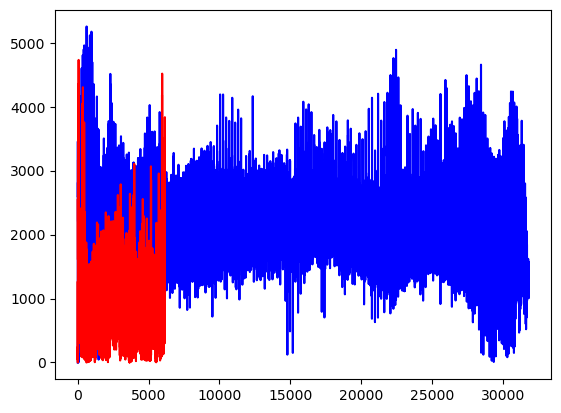

In [68]:
plt.plot(cape_ctl_xr, c='blue')
plt.plot(cape_def_xr, c='red')

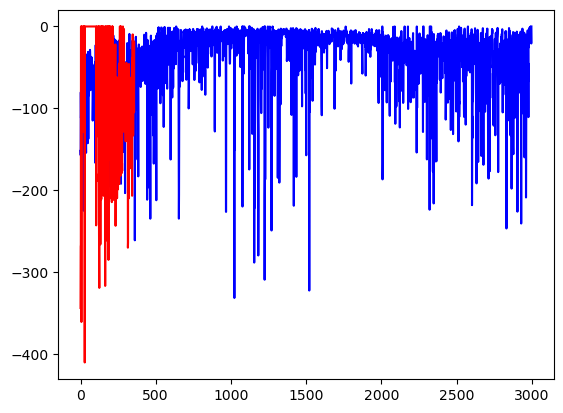

In [80]:
plt.plot(cin_ctl_xr, c='blue')
plt.plot(cin_def_xr, c='red')

_with xarray_

In [35]:
import metpy.calc as mpcalc
from metpy.units import units
import xarray as xr

def calc_cape_cin(pressure, temperature, dewpoint):
    """
    Compute CAPE and CIN for a single atmospheric profile.
    """
    # Convert to MetPy units
    pressure = pressure * units.hPa
    temperature = temperature * units.degC
    dewpoint = dewpoint * units.degC

    # Calculate parcel profile
    parcel_prof = mpcalc.parcel_profile(pressure, temperature[0], dewpoint[0])

    # Compute CAPE and CIN
    cape, cin = mpcalc.cape_cin(pressure, temperature, dewpoint, parcel_prof)

    return cape.magnitude, cin.magnitude  # Return values without units


In [36]:
# Apply the function across all locations
cape_cin_result_ctl = xr.apply_ufunc(
    calc_cape_cin,
    pressure_ctl,  # (plev, location)
    temperature_ctl,  # (plev, location)
    dewpoint_ctl,  # (plev, location)
    input_core_dims=[["plev"], ["plev"], ["plev"]],  
    output_core_dims=[[], []],  # CAPE and CIN are scalars
    vectorize=True,  # Apply function to each location independently
    dask="forbidden",  # Use Dask for parallel computation if applicable
    output_dtypes=[float, float]
)

In [37]:
# Apply the function across all locations
cape_cin_result_def = xr.apply_ufunc(
    calc_cape_cin,
    pressure_def,  # (plev, location)
    temperature_def,  # (plev, location)
    dewpoint_def,  # (plev, location)
    input_core_dims=[["plev"], ["plev"], ["plev"]],  
    output_core_dims=[[], []],  # CAPE and CIN are scalars
    vectorize=True,  # Apply function to each location independently
    dask="forbidden",  # Use Dask for parallel computation if applicable
    output_dtypes=[float, float]
)

In [38]:
# Assign CAPE and CIN to separate variables
cape_ctl = cape_cin_result_ctl[0]
cin_ctl = cape_cin_result_ctl[1]

In [39]:
# Assign CAPE and CIN to separate variables
cape_def = cape_cin_result_def[0]
cin_def = cape_cin_result_def[1]

_CTL_

In [40]:
d_file = '/scratch/m/m300948/test_04/pre_cape_cin_calculation/cape_ctl_6plus1_correct_02.nc'
ds_cape = cape_ctl.copy()
ds_cape["location"] = cape_ctl.metpy.dequantify()  # Keep the same dimensions
ds_cape["location"].attrs = {"units": "J/kg", "description": "CAPE"}

# Save the new dataset
ds_cape.to_netcdf(d_file)
print(f"Saved {d_file}")

Saved /scratch/m/m300948/test_04/pre_cape_cin_calculation/cape_ctl_6plus1_correct_02.nc


In [41]:
d_file = '/scratch/m/m300948/test_04/pre_cape_cin_calculation/cin_ctl_6plus1_correct_02.nc'
ds_cin = cin_ctl.copy()
ds_cin["location"] = cin_ctl.metpy.dequantify()  # Keep the same dimensions
ds_cin["location"].attrs = {"units": "J/kg", "description": "cin"}

# Save the new dataset
ds_cin.to_netcdf(d_file)
print(f"Saved {d_file}")

Saved /scratch/m/m300948/test_04/pre_cape_cin_calculation/cin_ctl_6plus1_correct_02.nc


_DEF_

In [42]:
d_file = '/scratch/m/m300948/def_100/pre_cape_cin_calculation/cape_def_6plus1_correct_02.nc'
ds_cape = cape_def.copy()
ds_cape["location"] = cape_def.metpy.dequantify()  # Keep the same dimensions
ds_cape["location"].attrs = {"units": "J/kg", "description": "CAPE"}

# Save the new dataset
ds_cape.to_netcdf(d_file)
print(f"Saved {d_file}")

Saved /scratch/m/m300948/def_100/pre_cape_cin_calculation/cape_def_6plus1_correct_02.nc


In [43]:
d_file = '/scratch/m/m300948/def_100/pre_cape_cin_calculation/cin_def_6plus1_correct_02.nc'
ds_cin = cin_def.copy()
ds_cin["location"] = cin_def.metpy.dequantify()  # Keep the same dimensions
ds_cin["location"].attrs = {"units": "J/kg", "description": "cin"}

# Save the new dataset
ds_cin.to_netcdf(d_file)
print(f"Saved {d_file}")

Saved /scratch/m/m300948/def_100/pre_cape_cin_calculation/cin_def_6plus1_correct_02.nc


/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/dask_jobqueue/core.py:255: FutureWarning: job_extra has been renamed to job_extra_directives. You are still using it (even if only set to []; please also check config files). If you did not set job_extra_directives yet, job_extra will be respected for now, but it will be removed in a future release. If you already set job_extra_directives, job_extra is ignored and you can remove it.
  warnings.warn(warn, FutureWarning)
/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/dask_jobqueue/slurm.py:49: FutureWarning: project has been renamed to account as this kwarg was used wit -A option. You are still using it (please also check config files). If you did not set account yet, project will be respected for now, but it will be removed in a future release. If you already set account, project is ignored and you can remove it.
  warnings.warn(warn, FutureWarning)


# Try with the original data - Chatgpt

In [19]:
data_path_td_ctl = '/scratch/m/m300948/test_04/3d/dew_point_temp/'
ta_ctl = xr.open_mfdataset(data_path_td_ctl+'ctl_daily_td_plev_20220101*', lock=False)['ta'] #chunks={'time': 1, 'plev': -1, 'lat': -1, 'lon': -1}
td_ctl = xr.open_mfdataset(data_path_td_ctl+'ctl_daily_td_plev_20220101*', lock=False)['td']

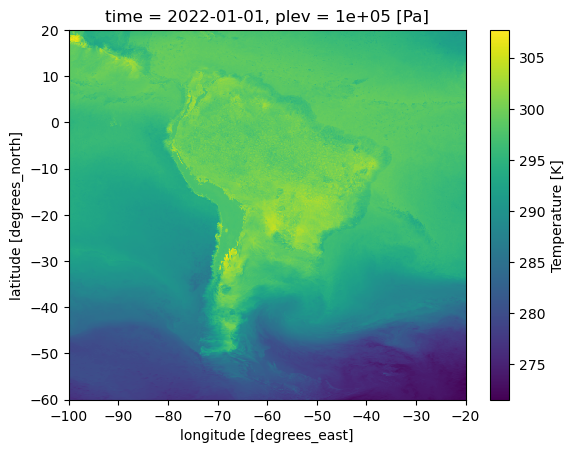

In [16]:
ta_ctl.isel(time=0, plev=0).plot()

In [20]:
td_ctl

<xarray.DataArray 'td' (time: 4, plev: 23, lat: 800, lon: 800)>
dask.array<open_dataset-b6614077c614910046580c5e3d9f3f9etd, shape=(4, 23, 800, 800), dtype=float64, chunksize=(4, 23, 800, 800), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 2022-01-01 ... 2022-01-01T18:00:00
  * lon      (lon) float64 -99.95 -99.85 -99.75 -99.65 ... -20.25 -20.15 -20.05
  * lat      (lat) float64 -59.95 -59.85 -59.75 -59.65 ... 19.75 19.85 19.95
  * plev     (plev) float64 1e+05 9.75e+04 9.5e+04 ... 3e+03 1e+03 100.0
Attributes:
    units:        degC
    description:  dew point temperature

In [9]:
from metpy.units import units
import metpy.calc as mpcalc

def calc_most_unstable_cape_cin(p, T, Td):
    p = p * units.hPa
    T = T * units.degC
    Td = Td * units.degC
    
    cape, cin = mpcalc.most_unstable_cape_cin(p, T, Td)
    return cape.magnitude, cin.magnitude

In [33]:
ta_ctl = ta_ctl.compute()
td_ctl = td_ctl.compute()

In [34]:
cape_da, cin_da = xr.apply_ufunc(
    calc_most_unstable_cape_cin,
    ta_ctl.isel(time=0).plev,
    ta_ctl.isel(time=0),
    td_ctl.isel(time=0),
    input_core_dims=[["plev"], ["plev"], ["plev"]],
    output_core_dims=[[], []],
    vectorize=True,
    dask="parallelized",
    output_dtypes=[float, float]
)

KeyboardInterrupt: 

In [27]:
ta_ctl

<xarray.DataArray 'ta' (time: 4, plev: 23, lat: 800, lon: 800)>
dask.array<open_dataset-b6614077c614910046580c5e3d9f3f9eta, shape=(4, 23, 800, 800), dtype=float32, chunksize=(4, 23, 800, 800), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 2022-01-01 ... 2022-01-01T18:00:00
  * lon      (lon) float64 -99.95 -99.85 -99.75 -99.65 ... -20.25 -20.15 -20.05
  * lat      (lat) float64 -59.95 -59.85 -59.75 -59.65 ... 19.75 19.85 19.95
  * plev     (plev) float64 1e+05 9.75e+04 9.5e+04 ... 3e+03 1e+03 100.0
Attributes:
    standard_name:  air_temperature
    long_name:      Temperature
    units:          K
    param:          0.0.0

In [32]:
cape_da.plot()

2025-02-06 08:13:56,930 - distributed.protocol.pickle - ERROR - Failed to serialize <ToPickle: HighLevelGraph with 1 layers.
 0. 140734124264960
>.
Traceback (most recent call last):
  File "/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/distributed/protocol/pickle.py", line 77, in dumps
    result = cloudpickle.dumps(x, **dump_kwargs)
  File "/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/cloudpickle/cloudpickle_fast.py", line 73, in dumps
    cp.dump(obj)
  File "/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/cloudpickle/cloudpickle_fast.py", line 632, in dump
    return Pickler.dump(self, obj)
TypeError: cannot pickle 'weakref.ReferenceType' object

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/distributed/protocol

TypeError: ('Could not serialize object of type HighLevelGraph', '<ToPickle: HighLevelGraph with 1 layers.\n<dask.highlevelgraph.HighLevelGraph object at 0x7fff3cf975e0>\n 0. 140734124264960\n>')